In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install google-cloud-vision
!pip install pdf2image
!apt-get install -y poppler-utils

In [ ]:
import os
import io
import csv
from pdf2image import convert_from_path
from google.cloud import vision

#configuración de Google Cloud Vision
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/content/drive/MyDrive/Dataset/google-ocr.json"
client = vision.ImageAnnotatorClient()

# directorios de entrada (pdfs) y salida (OCR)
BASE_DIR = "/content/drive/MyDrive/Dataset/JW_Org_Quechua_Spanish"
folders = {
    "esp": os.path.join(BASE_DIR, "esp"),
    "quz": os.path.join(BASE_DIR, "quz")
}
output_folder = os.path.join(BASE_DIR, "OCR_Texts")  # carpeta de salida
os.makedirs(output_folder, exist_ok=True)  # crear dicha carpeta si no existe

#función para extraer texto de una imagen con api de Google OCR
def extract_text_google_vision(image_path):
    """Extrae texto de una imagen usando Google Cloud Vision API"""
    with io.open(image_path, 'rb') as image_file:
        content = image_file.read()

    image = vision.Image(content=content)
    response = client.text_detection(image=image)
    texts = response.text_annotations

    if texts:
        return texts[0].description.strip()  # Eliminación de espacios extra

    return ""

# procesar pdfs en ambas carpetas
for lang, folder in folders.items():
    lang_output_folder = os.path.join(output_folder, lang)  # carpeta de salida por idioma
    os.makedirs(lang_output_folder, exist_ok=True)  # crear si no existe (por idioma)

    for file in sorted(os.listdir(folder)):
        if not file.endswith(".pdf"):
            continue

        pdf_path = os.path.join(folder, file)
        output_tsv_path = os.path.join(lang_output_folder, file.replace(".pdf", ".tsv"))

        # evitar reprocesar si ya existe
        if os.path.exists(output_tsv_path):
            print(f"Ya procesado: {output_tsv_path}")
            continue

        print(f"Procesando: {pdf_path} ...")

        # convertir PDF a imágenes para aplicar el OCR
        images = convert_from_path(pdf_path, dpi=300)

        #extraer texto de cada página
        extracted_data = []
        for i, image in enumerate(images):
            image_path = f"temp_page_{i+1}.jpg"
            image.save(image_path, "JPEG")  # guardar temporalmente en el espacio de trabajo de colab

            text = extract_text_google_vision(image_path)
            if text:
                extracted_data.append([i + 1, text])  # guardar número de página y texto correspondiente

            os.remove(image_path)  #eliminar imagen temporal

        #guardar en TSV solo si hay texto extraído
        if extracted_data:
            with open(output_tsv_path, "w", encoding="utf-8", newline="") as f:
                writer = csv.writer(f, delimiter="\t")
                writer.writerow(["pagina", "texto"])  #cabecera del tsv
                writer.writerows(extracted_data)

            print(f"Guardado: {output_tsv_path}")
        else:
            print(f"No se detectó texto en {pdf_path}.")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import re

#función para limpiar texto:
#saltos de línea, normalizar espacios, eliminar símbolos no deseados (no alfabéticos)
def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.replace('\n', ' ')
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'[^\w\s.,;:!?¿¡"()\'\-áéíóúñÁÉÍÓÚÑ]', '', text)
    return text

#definir rutas base para guardar versión limpia
base_input = "/content/drive/MyDrive/Dataset/JW_Org_Quechua_Spanish/OCR_Texts"
base_output = "/content/drive/MyDrive/Dataset/JW_Org_Quechua_Spanish/OCR_Cleaned_Texts"

for lang in ["esp", "quz"]:
    input_folder = os.path.join(base_input, lang)
    output_folder = os.path.join(base_output, lang)
    os.makedirs(output_folder, exist_ok=True)

    for filename in sorted(os.listdir(input_folder)):
        if not filename.endswith(".tsv"):
            continue

        file_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)

        try:
            df = pd.read_csv(file_path, sep="\t", encoding="utf-8")
            if "texto" not in df.columns:
                print(f"No se encontró columna 'texto' en: {filename}")
                continue

            df["texto"] = df["texto"].apply(clean_text)
            df.to_csv(output_path, sep="\t", index=False, encoding="utf-8")
            print(f"Archivo limpio guardado: {output_path}")

        except Exception as e:
            print(f"Error procesando {filename}: {e}")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import pandas as pd
import re

#correcciones ortográficas para el quechua collao (glotalizado o aspirado) obtenidas de Manual de escritura
correcciones = {
    r'\bnuqa\b|\bnoqa\b': 'ñuqa',
    r'\bnuqawan\b|\bnoqawan\b': 'ñuqawan',
    r'\bqulqi\b|\bqolqe\b|\bqollqe\b': 'qullqi',
    r'\bsalqa\b|\bsalq’a\b': 'sallqa',
    r'\btanpa\b|\bt\'anpa\b': "t'ampa",
    r'\bmachkay\b|\bmashkay\b': 'maskhay',
    r'\bjawapi\b|\bqawapi\b': 'hawapi',
    r'\balqu\b|\balqo\b|\ballku\b': 'allqu',
    r'\bluqu\b|\bruqhu\b': 'ruqu',
    r'\bllihlla\b|\blliqlla\b': 'lliklla',
    r'\bqatun\b|\bjatun\b|\batun\b': 'hatun',
    r'\bjampi\b|\bqampi\b': 'hampi',
    r'\bwashka\b|\bwachka\b': 'waskha',
    r'\bkuchka\b|\bkushka\b': 'kuska',
    r'\bmijuna\b|\bmihuna\b': 'mikhuna',
    r'\blaphi\b|\brap’i\b|\blapi\b': 'raphi',
    r'\bhayay\b|\bjayay\b': 'qayay',
    r'\bwaq’ay\b|\bwahay\b|\bwajay\b': 'waqay',
    r'\bkilli\b|\bkhilli\b': 'qhilli',
    r'\bqhillu\b|\bk\'illu\b|\bkillu\b': "q'illu",
    r'\ballim\b': 'allin',
    r'\bwasimpi\b': 'wasinpi',
    r'\bpijchu\b|\bpihchu\b|\bpiqchu\b': 'pikchu',
    r'\bhuaita\b': 'wayta',
    r'\bmaitu\b': "mayt'u",
    r'\bhuauqei\b': 'wawqiy',
    r'\bccatimuhuay\b': 'qatimuway',
    r'\bhuaina\b': 'wayna',
    r'\byahuar\b': 'yawar',
    r'\bpishqa\b|\bpisqa\b|\bphisqa\b': 'pichqa',
    r'\bashka\b|\baskha\b': 'achka',
    r'\bch\'uqay\b|\bchhuqay\b': 'chuqay',
    r'\bwisq\'ay\b|\bwishqay\b': "wichq'ay",
    r'\bhuq\b|\bhuj\b': 'huk',
    r'\bkhayra\b|\bq\'ayra\b': "k'ayra",
    r'\bchiqaq\b': 'chiqap',
    r'\bllamphu\b': "llamp'u",
    r'\bhaykaq\b|\bhayk\'aq\b': "hayk'ap",
    r'\bhata\b|\bkhata\b': 'qhata',
    r'\busqaylla\b|\buthqaylla\b': 'utqaylla',
    r'\bqasqi\b': 'qatqi',
    r'\bt\'iqtiy\b|\btiqthiy\b|\btiqt\'iy\b': 'tiqtiy',
    r'\bllant\'u\b': "llanthu",
}

def corregir_texto(texto, log):
    palabras = texto.split()
    corregidas = []

    for palabra in palabras:
        original = palabra
        for patron, reemplazo in correcciones.items():
            if re.fullmatch(patron, palabra):
                log.append((original, reemplazo))
                palabra = reemplazo
                break
        corregidas.append(palabra)

    return ' '.join(corregidas)

#rutas de export
input_path = "/content/drive/MyDrive/Dataset/JW_Org_Quechua_Spanish/OCR_Cleaned_Texts/quz"
output_path = "/content/drive/MyDrive/Dataset/JW_Org_Quechua_Spanish/OCR_Standardized_Texts/quz"
log_path = "/content/drive/MyDrive/Dataset/JW_Org_Quechua_Spanish/OCR_Standardized_Texts/quz_logs"

os.makedirs(output_path, exist_ok=True)
os.makedirs(log_path, exist_ok=True)

#procesamiento de archivos
for archivo in sorted(os.listdir(input_path)):
    if not archivo.endswith(".tsv"):
        continue

    input_file = os.path.join(input_path, archivo)
    output_file = os.path.join(output_path, archivo)
    log_file = os.path.join(log_path, archivo.replace(".tsv", "_log.txt"))

    df = pd.read_csv(input_file, sep="\t", encoding="utf-8")
    if "texto" not in df.columns:
        print(f"No se encontró columna 'texto' en {archivo}")
        continue

    cambios = []
    df["texto"] = df["texto"].apply(lambda t: corregir_texto(t, cambios))
    df.to_csv(output_file, sep="\t", index=False, encoding="utf-8")

    with open(log_file, "w", encoding="utf-8") as f:
        for original, corregido in cambios:
            f.write(f"{original} → {corregido}\n")

    print(f"{archivo} corregido. Cambios: {len(cambios)}")

In [ ]:
import pandas as pd
import os
import re

#patrón de puntuación seguida de mayúscula
def split_oraciones(texto):
    return re.split(r'(?<=[.?!])\s+(?=[A-ZÁÉÍÓÚÑ])', texto.strip())

def calcular_metadata(tsv_path):
    try:
        df = pd.read_csv(tsv_path, sep="\t", encoding="utf-8")
        texto_completo = " ".join(df["texto"].dropna().tolist())
        oraciones = split_oraciones(texto_completo)
        palabras = texto_completo.split()
        palabras_unicas = set(palabras)

        return {
            "Documento": os.path.basename(tsv_path),
            "N° Oraciones": len(oraciones),
            "Palabras Totales": len(palabras),
            "Palabras Únicas": len(palabras_unicas)
        }
    except Exception as e:
        print(f"Error procesando {tsv_path}: {e}")
        return None

#carpeta de tsv (el input)
base_input = "/content/drive/MyDrive/Dataset/JW_Org_Quechua_Spanish/OCR_Cleaned_Texts"

resultados = []

for lang in ["esp", "quz"]:
    input_folder = os.path.join(base_input, lang)
    for filename in sorted(os.listdir(input_folder)):
        if not filename.endswith(".tsv"):
            continue
        path = os.path.join(input_folder, filename)
        metadata = calcular_metadata(path)
        if metadata:
            metadata["Idioma"] = lang
            resultados.append(metadata)

#guardar a csv
df_resultado = pd.DataFrame(resultados)
output_csv = "/content/drive/MyDrive/Dataset/JW_Org_Quechua_Spanish/outputs/estadisticas_JW.csv"
os.makedirs(os.path.dirname(output_csv), exist_ok=True)
df_resultado.to_csv(output_csv, index=False, encoding="utf-8")
print(f"Metadata guardada en: {output_csv}")

Metadata guardada en: /content/drive/MyDrive/Dataset/JW_Org_Quechua_Spanish/outputs/estadisticas_JW.csv


In [ ]:
# Pivotear y guardar como CSV vertical
pivotado = resumen_por_idioma.set_index("Idioma").T.reset_index()
pivotado.columns.name = None
pivotado = pivotado.rename(columns={"index": "Métrica"})

# Guardar CSV final
output_csv = "/content/drive/MyDrive/Dataset/JW_Org_Quechua_Spanish/outputs/estadisticas_JW_pivot.csv"
pivotado.to_csv(output_csv, index=False)
print(f"Guardado en: {output_csv}")
display(pivotado)

Guardado en: /content/drive/MyDrive/Dataset/JW_Org_Quechua_Spanish/outputs/estadisticas_JW_pivot.csv


,Métrica,esp,quz
0,Documentos,67.00,67.00
1,Oraciones (prom),309.37,304.78
2,Oraciones (min),138.00,143.00
3,Oraciones (max),625.00,666.00
4,Palabras Totales (prom),6402.73,4093.78
5,Palabras Totales (min),3077.00,2035.00
6,Palabras Totales (max),14679.00,9265.00
7,Palabras Únicas (prom),2624.70,2575.36
8,Palabras Únicas (min),1356.00,1329.00
9,Palabras Únicas (max),5804.00,5231.00


In [ ]:
!pip install PyMuPDF

In [ ]:
import fitz  # PyMuPDF
import re
pdf_path = "/content/drive/MyDrive/Dataset/Documentos_Oficiales_MINEDU/DocumentosPDF/dicc_cusco.pdf"
doc = fitz.open(pdf_path)

#extraer texto de las páginas 9 a 182 (solo contenido paralelo)
raw_text = ""
for page_num in range(8, 182):
    page = doc.load_page(page_num)
    raw_text += page.get_text() + "\n"
doc.close()

#preprocesamiento 1: Unir palabras separadas por guion y salto de línea
raw_text = re.sub(r"(\w+)-\s*\n(\w+)", r"\1\2", raw_text)

# preprocesamiento 2: Eliminar cabeceras tipo "A\na - a" del diccionario
raw_text = re.sub(r"\n?[A-ZÑ]{1,2}\n[a-zñáéíóúü]+ ?- ?[a-zñáéíóúü]+\n?", "", raw_text)

#preprocesamiento 3: Normalizar saltos de línea múltiples
raw_text = re.sub(r"\n{2,}", "\n", raw_text)

#preprocesamiento 4: Eliminar líneas que son solo números de página
raw_text = re.sub(r"\n\d{2,3}(?=\n)", "\n", raw_text)

#mostrar algo del texto
#print(raw_text[:2000])

In [ ]:
import re

#regex para detectar inicio de entrada (palabras o palabras compuestas)
entrada_pattern = re.compile(r"^[A-ZÑÁÉÍÓÚÜ][A-ZÑa-zñáéíóúü’‘ʼ\- ]+\.\s*\([a-z,; \(\)\.]+\)")

#segmentar el texto en entradas individuales
entradas = []
entrada_actual = []

for linea in raw_text.splitlines():
    if entrada_pattern.match(linea.strip()):
        if entrada_actual:
            entradas.append("\n".join(entrada_actual).strip())
            entrada_actual = []
    entrada_actual.append(linea)

# unir entradas si están partidas por página siguiente o columna siguiente
if entrada_actual:
    entradas.append("\n".join(entrada_actual).strip())

# revisar visualmente algunas entradas
#for i, entrada in enumerate(entradas[63:68], 64):
#    print(f"\n--- Entrada {i} ---\n{entrada[:700]}...\n")

In [ ]:
def procesar_entrada(entrada):
    cabecera_match = re.match(r"^([A-ZÑa-zñáéíóúü’‘ʼ\- ]+)\. *\(([a-z,; \(\)\.]+)\)", entrada)
    if not cabecera_match:
        return None

    entrada_palabra = cabecera_match.group(1).strip()
    etiquetas = cabecera_match.group(2).strip()
    cuerpo = entrada[cabecera_match.end():].strip()

    enumerado = bool(re.search(r"(?:^|\n)1\.", cuerpo))
    ejemplos = []

    if enumerado:
        definicion_partes = re.split(r"\n1\.", cuerpo, maxsplit=1)
        definicion = definicion_partes[0].strip().replace("\n", " ")
        ejemplos_raw = "1." + definicion_partes[1] if len(definicion_partes) > 1 else ""
        bloques = re.split(r"\n\d+\.", ejemplos_raw)
        for bloque in bloques:
            parts = bloque.strip().split("\n-")
            if len(parts) == 2:
                quechua = parts[0].strip().replace("\n", " ")
                quechua = re.sub(r"^\d+\.\s*", "", quechua)
                esp = parts[1].strip().replace("\n", " ")
                ejemplos.append([quechua, esp])
            elif len(parts) > 2:
                quechua = parts[0].strip().replace("\n", " ")
                quechua = re.sub(r"^\d+\.\s*", "", quechua)
                esp = " ".join(p.strip().replace("\n", " ") for p in parts[1:])
                ejemplos.append([quechua, esp])
    else:
        cuerpo = re.sub(r"\.\s*-\s*", ".\n-", cuerpo)
        partes = cuerpo.split("\n-")
        definicion = partes[0].strip().replace("\n", " ")
        bloques = partes[1:]

        i = 0
        while i < len(bloques):
            bloque = bloques[i].strip().split("\n")
            if len(bloque) >= 2 and bloque[1][:1].isupper():
                quechua = bloque[0].strip().replace("\n", " ")
                esp = bloque[1].strip().replace("\n", " ")
                ejemplos.append([quechua, esp])
                i += 1
            elif i+1 < len(bloques):
                quechua = bloques[i].strip().replace("\n", " ")
                esp = bloques[i+1].strip().replace("\n", " ")
                ejemplos.append([quechua, esp])
                i += 2
            else:
                i += 1

    return {
        "entrada": entrada_palabra,
        "definicion_quechua": definicion,
        "ejemplos": ejemplos
    }

In [ ]:
registros = []
for e in entradas:
    resultado = procesar_entrada(e)
    if resultado:
        registros.append({
            "entrada": resultado["entrada"],
            "definicion_quechua": resultado["definicion_quechua"],
            "ejemplos": str(resultado["ejemplos"])
        })

import pandas as pd
df = pd.DataFrame(registros)
df.to_csv("/content/drive/MyDrive/Dataset/Documentos_Oficiales_MINEDU/TextoExtraido/glosario_minedu.tsv", sep="\t", index=False)
df.head(10)

,entrada,definicion_quechua,ejemplos
0,Achalay,". Sumaq p’acha churakuypas, uyanchikta mayllak...",[['Sipaskunaqa ñawraq llimp’i t’ikawanmi chuku...
1,Achanqaray,. Watan watan payllamanta kawsaq hatun yuraqpa...,[['Ñawpaqqa sipaskunapas warmikunapas achanqar...
2,Achikyay,". Intipas ninapas sansapas, illapapas rirpupas...",[['Ñan purikuq runaqa sansapa achikyayninta ri...
3,Achira,". Munay t’ikayuq, hatuchaq rapiyuq papahina ha...",[['Kurpus raymipaqqa Qusquman achira watyasqat...
4,Achka,". Chanin, sinchi, mana pisichu, mana yupay ati...",[['Achka hak’akllukunam chay t’uqupiqa puñusqa...
5,Achiwa,. Llanthukunapaq k’aspichakunaman ima awasqapa...,"[['Kunan p’unchawqa awasaqmi, mana ruphaykuwan..."
6,Achiyuti,. Yunkakunapi wiñaq kichka qarachapi puka ruru...,[['Aychataqa achiyuti tupachisqawan kankanapaq...
7,Achuqalla,". Aycha mikhuq. Yaqa quwi sayaylla, tuta puriy...","[['Punkuta allinta wichq’aychik, paqtataq achu..."
8,Achuqcha,. Yunkakunapi arwispa wiñaq yura; rurunqa mikh...,[['Achuqchataqa ruqututahina hunt’achispam way...
9,Aka,. 1. Runakunapa mikhusqankupa puchunta uqutint...,"[['Akapiqa ch’uspi huñukun.', 'En el excrement..."


In [ ]:
#path de export
output_path = "/content/drive/MyDrive/Dataset/Documentos_Oficiales_MINEDU/TextoExtraido/glosario_minedu.tsv"

#guardar tsv
df.to_csv(output_path, sep="\t", index=False)

print(f"Archivo guardado en: {output_path}")

Archivo guardado en: /content/drive/MyDrive/Dataset/Documentos_Oficiales_MINEDU/TextoExtraido/glosario_minedu.tsv


In [ ]:
import pandas as pd
import ast
import re
import os
import math

#ruta del tsv procesado
tsv_path = "/content/drive/MyDrive/Dataset/Documentos_Oficiales_MINEDU/TextoExtraido/glosario_minedu.tsv"
df = pd.read_csv(tsv_path, sep="\t")

def contar_oraciones(texto):
    if pd.isna(texto):
        return 0
    return len(re.findall(r'[.!?]\s', texto)) + (1 if texto.strip() else 0)

n_total = len(df)
n_grupos = 3
tamaño_grupo = math.ceil(n_total / n_grupos)

resultados_quz = []
resultados_esp = []

for i in range(n_grupos):
    inicio = i * tamaño_grupo
    fin = min((i + 1) * tamaño_grupo, n_total)
    bloque = df.iloc[inicio:fin]

    textos_quz = bloque["definicion_quechua"].fillna("").tolist()
    textos_esp = []

    ejemplos_bloque = bloque["ejemplos"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

    for ejemplos in ejemplos_bloque:
        for par in ejemplos:
            textos_quz.append(par[0])
            textos_esp.append(par[1])

    texto_quz = " ".join(textos_quz)
    texto_esp = " ".join(textos_esp)

    resultados_quz.append({
        "N° Oraciones": contar_oraciones(texto_quz),
        "Palabras Totales": len(texto_quz.split()),
        "Palabras Únicas": len(set(texto_quz.split()))
    })

    resultados_esp.append({
        "N° Oraciones": contar_oraciones(texto_esp),
        "Palabras Totales": len(texto_esp.split()),
        "Palabras Únicas": len(set(texto_esp.split()))
    })

df_quz = pd.DataFrame(resultados_quz)
df_esp = pd.DataFrame(resultados_esp)

resumen = pd.DataFrame({
    "Métrica": [
        "Documentos",
        "Oraciones (prom)", "Oraciones (min)", "Oraciones (max)",
        "Palabras Totales (prom)", "Palabras Totales (min)", "Palabras Totales (max)",
        "Palabras Únicas (prom)", "Palabras Únicas (min)", "Palabras Únicas (max)"
    ],
    "quz": [
        len(df_quz),
        round(df_quz["N° Oraciones"].mean(), 2), df_quz["N° Oraciones"].min(), df_quz["N° Oraciones"].max(),
        round(df_quz["Palabras Totales"].mean(), 2), df_quz["Palabras Totales"].min(), df_quz["Palabras Totales"].max(),
        round(df_quz["Palabras Únicas"].mean(), 2), df_quz["Palabras Únicas"].min(), df_quz["Palabras Únicas"].max()
    ],
    "esp": [
        len(df_esp),
        round(df_esp["N° Oraciones"].mean(), 2), df_esp["N° Oraciones"].min(), df_esp["N° Oraciones"].max(),
        round(df_esp["Palabras Totales"].mean(), 2), df_esp["Palabras Totales"].min(), df_esp["Palabras Totales"].max(),
        round(df_esp["Palabras Únicas"].mean(), 2), df_esp["Palabras Únicas"].min(), df_esp["Palabras Únicas"].max()
    ]
})

#guardar csv
output_path = "/content/drive/MyDrive/Dataset/Documentos_Oficiales_MINEDU/outputs/estadisticas_minedu.csv"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
resumen.to_csv(output_path, index=False)

print(resumen)
print(f"Guardado en: {output_path}")

                   Métrica      quz      esp
0               Documentos     3.00     3.00
1         Oraciones (prom)  2017.67   535.33
2          Oraciones (min)  1941.00   470.00
3          Oraciones (max)  2146.00   643.00
4  Palabras Totales (prom)  8175.67  6865.67
5   Palabras Totales (min)  7262.00  5147.00
6   Palabras Totales (max)  9492.00  9264.00
7   Palabras Únicas (prom)  5276.67  2738.33
8    Palabras Únicas (min)  4826.00  2186.00
9    Palabras Únicas (max)  5992.00  3486.00
Guardado en: /content/drive/MyDrive/Dataset/Documentos_Oficiales_MINEDU/outputs/estadisticas_minedu.csv


In [ ]:
import pandas as pd
import ast
import re
import os

#ruta al tsv procesado
tsv_path = "/content/drive/MyDrive/Dataset/Documentos_Oficiales_MINEDU/TextoExtraido/glosario_minedu.tsv"
df = pd.read_csv(tsv_path, sep="\t")

def contar_oraciones(texto):
    if pd.isna(texto):
        return 0
    return len(re.findall(r'[.!?]\s', texto)) + (1 if texto.strip() else 0)

ejemplos_lista = df["ejemplos"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])
ejemplos_flat = [par for ejemplos in ejemplos_lista for par in ejemplos]

n_total = len(ejemplos_flat)
proporciones = [241/569, 164/569, 164/569]
tamaños = [int(n_total * p) for p in proporciones]
tamaños[-1] = n_total - sum(tamaños[:-1])

resultados_quz = []
resultados_esp = []

inicio = 0
for tam in tamaños:
    fin = inicio + tam
    bloque = ejemplos_flat[inicio:fin]

    textos_quz = [par[0] for par in bloque]
    textos_esp = [par[1] for par in bloque]

    texto_quz = " ".join(textos_quz)
    texto_esp = " ".join(textos_esp)

    resultados_quz.append({
        "N° Oraciones": contar_oraciones(texto_quz),
        "Palabras Totales": len(texto_quz.split()),
        "Palabras Únicas": len(set(texto_quz.split()))
    })

    resultados_esp.append({
        "N° Oraciones": contar_oraciones(texto_esp),
        "Palabras Totales": len(texto_esp.split()),
        "Palabras Únicas": len(set(texto_esp.split()))
    })

    inicio = fin

df_quz = pd.DataFrame(resultados_quz)
df_esp = pd.DataFrame(resultados_esp)

resumen = pd.DataFrame({
    "Métrica": [
        "Documentos",
        "Oraciones (prom)", "Oraciones (min)", "Oraciones (max)",
        "Palabras Totales (prom)", "Palabras Totales (min)", "Palabras Totales (max)",
        "Palabras Únicas (prom)", "Palabras Únicas (min)", "Palabras Únicas (max)"
    ],
    "quz": [
        len(df_quz),
        round(df_quz["N° Oraciones"].mean(), 2), df_quz["N° Oraciones"].min(), df_quz["N° Oraciones"].max(),
        round(df_quz["Palabras Totales"].mean(), 2), df_quz["Palabras Totales"].min(), df_quz["Palabras Totales"].max(),
        round(df_quz["Palabras Únicas"].mean(), 2), df_quz["Palabras Únicas"].min(), df_quz["Palabras Únicas"].max()
    ],
    "esp": [
        len(df_esp),
        round(df_esp["N° Oraciones"].mean(), 2), df_esp["N° Oraciones"].min(), df_esp["N° Oraciones"].max(),
        round(df_esp["Palabras Totales"].mean(), 2), df_esp["Palabras Totales"].min(), df_esp["Palabras Totales"].max(),
        round(df_esp["Palabras Únicas"].mean(), 2), df_esp["Palabras Únicas"].min(), df_esp["Palabras Únicas"].max()
    ]
})

#guardar csv
output_path = "/content/drive/MyDrive/Dataset/Documentos_Oficiales_MINEDU/outputs/estadisticas_minedu.csv"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
resumen.to_csv(output_path, index=False)

print(resumen)
print(f"Guardado en: {output_path}")

                   Métrica      quz      esp
0               Documentos     3.00     3.00
1         Oraciones (prom)   511.67   535.33
2          Oraciones (min)   437.00   444.00
3          Oraciones (max)   568.00   595.00
4  Palabras Totales (prom)  3774.00  6865.67
5   Palabras Totales (min)  3323.00  5887.00
6   Palabras Totales (max)  4392.00  8146.00
7   Palabras Únicas (prom)  2809.00  2751.67
8    Palabras Únicas (min)  2480.00  2395.00
9    Palabras Únicas (max)  3172.00  3163.00
Guardado en: /content/drive/MyDrive/Dataset/Documentos_Oficiales_MINEDU/outputs/estadisticas_minedu.csv


In [ ]:
import pandas as pd
import os

# rutas input
path_jw = "/content/drive/MyDrive/Dataset/JW_Org_Quechua_Spanish/outputs/estadisticas_JW_pivot.csv"
path_minedu = "/content/drive/MyDrive/Dataset/Documentos_Oficiales_MINEDU/outputs/estadisticas_minedu.csv"

df_jw = pd.read_csv(path_jw)
df_minedu = pd.read_csv(path_minedu)

#unir por métrica
df = df_jw.merge(df_minedu, on="Métrica", suffixes=("_jw", "_minedu"))

doc_quz_total = df.loc[df["Métrica"] == "Documentos", "quz_jw"].values[0] + df.loc[df["Métrica"] == "Documentos", "quz_minedu"].values[0]
doc_esp_total = df.loc[df["Métrica"] == "Documentos", "esp_jw"].values[0] + df.loc[df["Métrica"] == "Documentos", "esp_minedu"].values[0]

def combinar_fila(fila):
    metrica = fila["Métrica"]

    if metrica == "Documentos":
        return {
            "Métrica": metrica,
            "quz": fila["quz_jw"] + fila["quz_minedu"],
            "esp": fila["esp_jw"] + fila["esp_minedu"]
        }
    elif "prom" in metrica:
        prom_quz = (
            fila["quz_jw"] * df.loc[df["Métrica"] == "Documentos", "quz_jw"].values[0] +
            fila["quz_minedu"] * df.loc[df["Métrica"] == "Documentos", "quz_minedu"].values[0]
        ) / doc_quz_total

        prom_esp = (
            fila["esp_jw"] * df.loc[df["Métrica"] == "Documentos", "esp_jw"].values[0] +
            fila["esp_minedu"] * df.loc[df["Métrica"] == "Documentos", "esp_minedu"].values[0]
        ) / doc_esp_total

        return {
            "Métrica": metrica,
            "quz": round(prom_quz, 2),
            "esp": round(prom_esp, 2)
        }
    elif "min" in metrica:
        return {
            "Métrica": metrica,
            "quz": min(fila["quz_jw"], fila["quz_minedu"]),
            "esp": min(fila["esp_jw"], fila["esp_minedu"])
        }
    elif "max" in metrica:
        return {
            "Métrica": metrica,
            "quz": max(fila["quz_jw"], fila["quz_minedu"]),
            "esp": max(fila["esp_jw"], fila["esp_minedu"])
        }
    else:
        return {"Métrica": metrica, "quz": None, "esp": None}

df_agregado = pd.DataFrame([combinar_fila(row) for _, row in df.iterrows()])

# Guardar como CSV
output_path = "/content/drive/MyDrive/Dataset/Comparativos/outputs/estadisticas_corpus_total.csv"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
df_agregado.to_csv(output_path, index=False)

print(df_agregado)
print(f"Guardado en: {output_path}")

**CONSOLIDADO CORPUS**

In [ ]:
#Rutas
MINEDU_PATH = "/content/drive/MyDrive/Dataset/Documentos_Oficiales_MINEDU/TextoExtraido/glosario_minedu.tsv"
JW_ES_DIR   = "/content/drive/MyDrive/Dataset/JW_Org_Quechua_Spanish/OCR_Cleaned_Texts/esp"
JW_QUZ_DIR  = "/content/drive/MyDrive/Dataset/JW_Org_Quechua_Spanish/OCR_Cleaned_Texts/quz"

OUT_DIR     = "/content/drive/MyDrive/Dataset/Corpus_Consolidado/outputs"  # OUTPUT PARA RESULTADOS
SAVE_FILES  = True  # Escribir CSV/Parquet/Metrics

import os
os.makedirs(OUT_DIR, exist_ok=True)
print("Rutas configuradas:", MINEDU_PATH, JW_ES_DIR, JW_QUZ_DIR, "| OUT_DIR:", OUT_DIR)

Rutas configuradas: /content/drive/MyDrive/Dataset/Documentos_Oficiales_MINEDU/TextoExtraido/glosario_minedu.tsv /content/drive/MyDrive/Dataset/JW_Org_Quechua_Spanish/OCR_Cleaned_Texts/esp /content/drive/MyDrive/Dataset/JW_Org_Quechua_Spanish/OCR_Cleaned_Texts/quz | OUT_DIR: /content/drive/MyDrive/Dataset/Corpus_Consolidado/outputs


In [ ]:
# imports
from __future__ import annotations
import os, re, json, glob
from dataclasses import dataclass
from typing import List, Tuple, Dict, Optional
import numpy as np
import pandas as pd

# limpieza y segmentacion
_pc_ws_re = re.compile(r"\s+")
_PC_ABBREV_ES = {"Sr.", "Sra.", "Dr.", "Dra.", "Ing.", "Lic.", "p.ej.", "etc.", "EE. UU.", "EE.UU."}
_PC_SENT_SPLIT_REGEX = r"(?<=[\.\?\!\u2026])\s+"  # ., ?, !, …

def pc_normalize_text(s: str) -> str:
    if s is None:
        return ""
    s = s.replace("\u00A0", " ")
    s = _pc_ws_re.sub(" ", s)
    return s.strip()

def pc_sentence_split_es(text: str) -> List[str]:
    text = pc_normalize_text(text)
    if not text:
        return []
    protected = {}
    tmp = text
    for i, ab in enumerate(sorted(_PC_ABBREV_ES, key=len, reverse=True)):
        key = f"[[ABR{i}]]"
        protected[key] = ab
        tmp = tmp.replace(ab, key)
    parts = re.split(_PC_SENT_SPLIT_REGEX, tmp)
    sents = []
    for p in parts:
        p = p.strip()
        if not p:
            continue
        for k, ab in protected.items():
            p = p.replace(k, ab)
        sents.append(p)
    return sents

def pc_sentence_split_quz(text: str) -> List[str]:
    text = pc_normalize_text(text)
    if not text:
        return []
    parts = re.split(_PC_SENT_SPLIT_REGEX, text)
    out = []
    for p in parts:
        p = p.strip()
        if not p:
            continue
        if out and len(p) < 6:
            out[-1] = (out[-1] + " " + p).strip()
        else:
            out.append(p)
    return out

In [ ]:
#PARALELO DE MINEDU
def pc_load_minedu_examples(minedu_path: str) -> pd.DataFrame:
    """
    TSV con columnas:
      - entrada
      - definicion_quechua
      - ejemplos -> string representando lista de pares [[quz, es], ...]
    Devuelve columnas estándar: doc_id, idx_sent, esp, quz, fuente, origen, alineacion_conflictiva, confianza, notas
    """
    df = pd.read_csv(minedu_path, sep="\t", dtype=str)
    df.columns = [c.strip().lower() for c in df.columns]
    assert "ejemplos" in df.columns, "El TSV MINEDU debe tener columna 'ejemplos'"

    rows = []
    for i, row in df.iterrows():
        raw = str(row["ejemplos"]).strip()
        if not raw:
            continue
        pairs = None
        try:
            pairs = json.loads(raw.replace("'", '"'))
        except Exception:
            import ast
            try:
                pairs = ast.literal_eval(raw)
            except Exception:
                pairs = None
        if not isinstance(pairs, (list, tuple)):
            continue

        for idx, par in enumerate(pairs):
            if not isinstance(par, (list, tuple)) or len(par) != 2:
                continue
            quz = pc_normalize_text(str(par[0]))
            esp = pc_normalize_text(str(par[1]))
            if not (quz and esp):
                continue
            rows.append({
                "doc_id": row.get("entrada", f"MINEDU_{i}") or f"MINEDU_{i}",
                "idx_sent": idx,
                "esp": esp,
                "quz": quz,
                "fuente": "MINEDU",
                "origen": "MINEDU",
                "alineacion_conflictiva": False,
                "confianza": 1.0,
                "notas": "ejemplo-paralelo"
            })
    out = pd.DataFrame(rows)
    print(f"[PC] MINEDU cargado: {len(out)} pares")
    return out

In [ ]:
# LECTURA JW ORG
def pc_read_jw_tsv(tsv_path: str) -> pd.DataFrame:
    df = pd.read_csv(tsv_path, sep="\t", dtype={"pagina":str, "texto":str})
    df.columns = [c.strip().lower() for c in df.columns]
    assert {"pagina","texto"}.issubset(df.columns), "TSV JW debe tener columnas pagina y texto"
    # orden por página
    try:
        df["pagina_num"] = df["pagina"].astype(int)
    except Exception:
        df["pagina_num"] = df["pagina"].factorize()[0]
    df = df.sort_values("pagina_num")
    return df

def pc_extract_doc_id(filename: str) -> str:
    # ejemplo: g_S_201301.tsv -> g_201301 ; g_QU_201301.tsv -> g_201301
    base = os.path.basename(filename)
    stem = os.path.splitext(base)[0]
    stem = stem.replace("_S_", "_").replace("_QU_", "_")
    return stem

In [ ]:
# Alineación JW ORG (longitud y anclas)
@dataclass
class PcAlignCfg:
    del_cost: float = 1.2     # penalización 1-0 / 0-1
    sub_cost: float = 0.35    # 1-1 por longitud
    join_cost: float = 0.6    # 2-1 / 1-2
    anchor_bonus: float = 0.15  # bonificación anclas

_PC_NUM_RE    = re.compile(r"\d+")
_PC_QUOTES_RE = re.compile(r"[\\\\\"'«»“”‘’]")
_PC_PERC_RE   = re.compile(r"%")

def _pc_len_cost(a: str, b: str) -> float:
    la, lb = max(1, len(a)), max(1, len(b))
    return abs(la - lb) / max(la, lb)

def _pc_anchor_overlap(a: str, b: str) -> float:
    score = 0.0
    nums_a = set(_PC_NUM_RE.findall(a))
    nums_b = set(_PC_NUM_RE.findall(b))
    if nums_a and nums_b and nums_a.intersection(nums_b):
        score += 0.5
    if _PC_PERC_RE.search(a) and _PC_PERC_RE.search(b):
        score += 0.3
    if _PC_QUOTES_RE.search(a) and _PC_QUOTES_RE.search(b):
        score += 0.2
    return min(score, 1.0)

def pc_align_len_with_anchors(es_sents: List[str], quz_sents: List[str], cfg: PcAlignCfg = PcAlignCfg()):
    """
    Devuelve lista de tuplas: ([idx_es...], [idx_quz...], confianza, conflictivo, nota)
    """
    n, m = len(es_sents), len(quz_sents)
    dp = np.full((n+1, m+1), np.inf)
    bt: Dict[Tuple[int,int], Tuple[int,int,str,float]] = {}
    dp[0,0] = 0.0

    def sub_cost(i,j):
        base  = cfg.sub_cost  * _pc_len_cost(es_sents[i], quz_sents[j])
        bonus = cfg.anchor_bonus * _pc_anchor_overlap(es_sents[i], quz_sents[j])
        return max(0.0, base - bonus)

    def join_cost_es(i,j):
        base  = cfg.join_cost * _pc_len_cost(es_sents[i] + " " + es_sents[i+1], quz_sents[j])
        bonus = cfg.anchor_bonus * _pc_anchor_overlap(es_sents[i] + " " + es_sents[i+1], quz_sents[j])
        return max(0.0, base - bonus)

    def join_cost_quz(i,j):
        base  = cfg.join_cost * _pc_len_cost(es_sents[i], quz_sents[j] + " " + quz_sents[j+1])
        bonus = cfg.anchor_bonus * _pc_anchor_overlap(es_sents[i], quz_sents[j] + " " + quz_sents[j+1])
        return max(0.0, base - bonus)

    for i in range(n+1):
        for j in range(m+1):
            if i < n and j < m:
                c = sub_cost(i,j)
                if dp[i,j] + c < dp[i+1,j+1]:
                    dp[i+1,j+1] = dp[i,j] + c
                    bt[(i+1,j+1)] = (i,j,'sub', c)
            if i+1 < n and j < m:  # 2-1
                c = join_cost_es(i,j)
                if dp[i,j] + c < dp[i+2,j+1]:
                    dp[i+2,j+1] = dp[i,j] + c
                    bt[(i+2,j+1)] = (i,j,'2-1', c)
            if i < n and j+1 < m:  # 1-2
                c = join_cost_quz(i,j)
                if dp[i,j] + c < dp[i+1,j+2]:
                    dp[i+1,j+2] = dp[i,j] + c
                    bt[(i+1,j+2)] = (i,j,'1-2', c)
            if i < n:  # 1-0
                c = cfg.del_cost
                if dp[i,j] + c < dp[i+1,j]:
                    dp[i+1,j] = dp[i,j] + c
                    bt[(i+1,j)] = (i,j,'1-0', c)
            if j < m:  # 0-1
                c = cfg.del_cost
                if dp[i,j] + c < dp[i,j+1]:
                    dp[i,j+1] = dp[i,j] + c
                    bt[(i,j+1)] = (i,j,'0-1', c)

    # backtrack
    pairs = []
    i, j = n, m
    while (i,j) in bt:
        pi, pj, kind, c = bt[(i,j)]
        if kind == 'sub':
            e = [i-1]; q = [j-1]; conflict = False; note = ''
        elif kind == '2-1':
            e = [i-2, i-1]; q = [j-1]; conflict = True; note = 'join-es(2-1)'
        elif kind == '1-2':
            e = [i-1]; q = [j-2, j-1]; conflict = True; note = 'join-quz(1-2)'
        elif kind == '1-0':
            e = [i-1]; q = []; conflict = True; note = '1-0'
        elif kind == '0-1':
            e = []; q = [j-1]; conflict = True; note = '0-1'
        else:
            e = []; q = []; conflict = True; note = '?'
        conf = float(np.exp(-c))  # confianza ~ e^{-c}
        pairs.append((e, q, conf, conflict, note))
        i, j = pi, pj
    pairs.reverse()
    return pairs

In [ ]:
# Alineación JW por documento
def pc_align_jw_pair(tsv_es: str, tsv_quz: str) -> pd.DataFrame:
    df_es = pc_read_jw_tsv(tsv_es)
    df_qu = pc_read_jw_tsv(tsv_quz)
    doc_id = pc_extract_doc_id(tsv_es)

    text_es = "\n".join(pc_normalize_text(t) for t in df_es["texto"].fillna("").tolist())
    text_qu = "\n".join(pc_normalize_text(t) for t in df_qu["texto"].fillna("").tolist())

    s_es = pc_sentence_split_es(text_es)
    s_qu = pc_sentence_split_quz(text_qu)

    pairs = pc_align_len_with_anchors(s_es, s_qu)

    rows = []
    idx_sent = 0
    for e_idx, q_idx, conf, conflict, note in pairs:
        esp = " ".join(s_es[i] for i in e_idx) if e_idx else ""
        quz = " ".join(s_qu[j] for j in q_idx) if q_idx else ""
        if esp and quz:
            rows.append({
                "doc_id": doc_id,
                "idx_sent": idx_sent,
                "esp": esp,
                "quz": quz,
                "fuente": "JW",
                "origen": "JW",
                "alineacion_conflictiva": bool(conflict),
                "confianza": float(conf),
                "notas": note
            })
            idx_sent += 1
    return pd.DataFrame(rows)

#Procesamiento por lotes JW
def pc_batch_align_jw(jw_es_dir: str, jw_quz_dir: str) -> pd.DataFrame:
    es_files = sorted(glob.glob(os.path.join(jw_es_dir, "*.tsv")))
    qu_files = sorted(glob.glob(os.path.join(jw_quz_dir, "*.tsv")))
    idx_qu = {pc_extract_doc_id(p): p for p in qu_files}

    out = []
    for es_path in es_files:
        doc_id = pc_extract_doc_id(es_path)
        qu_path = idx_qu.get(doc_id)
        if not qu_path:
            keynum = re.findall(r"\d+", doc_id)
            cand = None
            if keynum:
                suf = keynum[-1]
                for k, v in idx_qu.items():
                    if suf in k:
                        cand = v; break
            qu_path = cand

        if not qu_path:
            print("[PC][AVISO] No se encontró par QUZ para", es_path)
            continue

        df = pc_align_jw_pair(es_path, qu_path)
        out.append(df)

    if out:
        out = pd.concat(out, ignore_index=True)
    else:
        out = pd.DataFrame(columns=["doc_id","idx_sent","esp","quz","fuente","origen","alineacion_conflictiva","confianza","notas"])

    print(f"[PC] JW cargado: {len(out)} pares")
    return out

In [ ]:
# Corpus Consolidado JW ORG Y MINEDU (métricas)
def pc_consolidate(minedu_df: pd.DataFrame, jw_df: pd.DataFrame):
    """
    Unifica MINEDU + JW garantizando columnas estándar.
    Devuelve:
      - df_all: pares 1:1 con columnas base + longitudes de tokens
      - stats: métricas por doc_id/fuente (pares, palabras, conflictos, confianza)
    """
    df = pd.concat([minedu_df, jw_df], ignore_index=True)
    df = df.dropna(subset=["esp","quz"])
    df["id"] = np.arange(1, len(df)+1)
    df = df[["id","fuente","doc_id","idx_sent","esp","quz","origen","alineacion_conflictiva","confianza","notas"]]

    df["len_esp_tokens"] = df["esp"].str.split().map(len)
    df["len_quz_tokens"] = df["quz"].str.split().map(len)

    stats = (df.assign(par=1)
               .groupby(["doc_id","fuente"], as_index=False)
               .agg(
                    pares=("par","sum"),
                    oraciones_esp=("par","sum"),   # en 1:1, igual a 'pares'
                    oraciones_quz=("par","sum"),   # en 1:1, igual a 'pares'
                    palabras_esp_total=("len_esp_tokens","sum"),
                    palabras_quz_total=("len_quz_tokens","sum"),
                    conflictos=("alineacion_conflictiva","sum"),
                    confianza_prom=("confianza","mean")
               ))
    return df, stats

In [ ]:
#Ejecución
df_minedu = pc_load_minedu_examples(MINEDU_PATH)
df_jw     = pc_batch_align_jw(JW_ES_DIR, JW_QUZ_DIR)
df_all, stats = pc_consolidate(df_minedu, df_jw)

print("Resumen consolidado:")
print(f"  Total pares 1:1 = {len(df_all)}")
print(f"  Conflictos (JW) = {int(df_all['alineacion_conflictiva'].sum())}")
print("  Confianza promedio (global) =", round(df_all['confianza'].mean(), 3) if len(df_all) else "NA")

if SAVE_FILES:
    df_all.to_csv(os.path.join(OUT_DIR, "corpus_parallel_es_quz.csv"), index=False)
    try:
        df_all.to_parquet(os.path.join(OUT_DIR, "corpus_parallel_es_quz.parquet"), index=False)
    except Exception as e:
        print("[PC][AVISO] Parquet no disponible:", e)
    stats.to_csv(os.path.join(OUT_DIR, "metrics_por_documento.csv"), index=False)
    print("Escritos en", OUT_DIR)

NameError: name 'pc_load_minedu_examples' is not defined

In [ ]:
#Métricas finales
import os
import pandas as pd

def _carga_consolidado():
    # cargar de memoria
    if 'df_all' in globals() and isinstance(df_all, pd.DataFrame) and len(df_all):
        return df_all

    # cargar desde directorio
    candidatos = []
    if 'OUT_DIR' in globals():
        candidatos += [
            os.path.join(OUT_DIR, "corpus_parallel_es_quz.parquet"),
            os.path.join(OUT_DIR, "corpus_parallel_es_quz.csv"),
        ]
    candidatos += [
        os.path.join("out", "corpus_parallel_es_quz.parquet"),
        os.path.join("out", "corpus_parallel_es_quz.csv"),
    ]

    for path in candidatos:
        if os.path.exists(path):
            try:
                if path.endswith(".parquet"):
                    print(f"Cargando Parquet: {path}")
                    return pd.read_parquet(path)
                else:
                    print(f"Cargando CSV: {path}")
                    return pd.read_csv(path)
            except Exception as e:
                print("No se pudo cargar", path, "-", e)

    raise FileNotFoundError(
        "No se encontró df 'corpus_parallel_es_quz.(parquet|csv)'. "
        "SAVE_FILES=True"
    )

def metricas_consolidado_basicas(df: pd.DataFrame) -> pd.DataFrame:
    """
    Métricas relevantes para un consolidado paralelo 1:1:
      - Pares de oraciones (total)
      - Palabras totales (esp/quz)
      - Palabras únicas (esp/quz)
      - Tokens por oración (prom) (esp/quz)
    """
    n_pares = len(df)

    esp_tokens_por_sent = df["esp"].astype(str).str.split().map(len)
    quz_tokens_por_sent = df["quz"].astype(str).str.split().map(len)

    total_tokens_esp = int(esp_tokens_por_sent.sum())
    total_tokens_quz = int(quz_tokens_por_sent.sum())

    unique_tokens_esp = len({tok.lower() for sent in df["esp"].astype(str) for tok in sent.split()})
    unique_tokens_quz = len({tok.lower() for sent in df["quz"].astype(str) for tok in sent.split()})

    avg_tok_per_sent_esp = round(total_tokens_esp / n_pares, 2) if n_pares else 0.0
    avg_tok_per_sent_quz = round(total_tokens_quz / n_pares, 2) if n_pares else 0.0

    return pd.DataFrame({
        "Métrica": [
            "Pares de oraciones (total)",
            "Palabras Totales (total)",
            "Palabras Únicas (total)",
            "Tokens por oración (prom)"
        ],
        "esp": [n_pares, total_tokens_esp, unique_tokens_esp, avg_tok_per_sent_esp],
        "quz": [n_pares, total_tokens_quz, unique_tokens_quz, avg_tok_per_sent_quz],
    })

df_all = _carga_consolidado()
tabla_metricas_def = metricas_consolidado_basicas(df_all)
print("=== Métricas (consolidado 1:1) ===")
display(tabla_metricas_def)

if 'SAVE_FILES' in globals() and SAVE_FILES:
    out_dir = OUT_DIR if 'OUT_DIR' in globals() else "out"
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, "metricas_consolidado_definitivas.csv")
    tabla_metricas_def.to_csv(out_path, index=False)
    print("Métricas guardadas en:", out_path)

Cargando Parquet: /content/drive/MyDrive/Dataset/Corpus_Consolidado/outputs/corpus_parallel_es_quz.parquet
=== Métricas (consolidado 1:1) ===


,Métrica,esp,quz
0,Pares de oraciones (total),22581.00,22581.00
1,Palabras Totales (total),449580.00,285605.00
2,Palabras Únicas (total),52632.00,73637.00
3,Tokens por oración (prom),19.91,12.65


Métricas guardadas en: /content/drive/MyDrive/Dataset/Corpus_Consolidado/outputs/metricas_consolidado_definitivas.csv


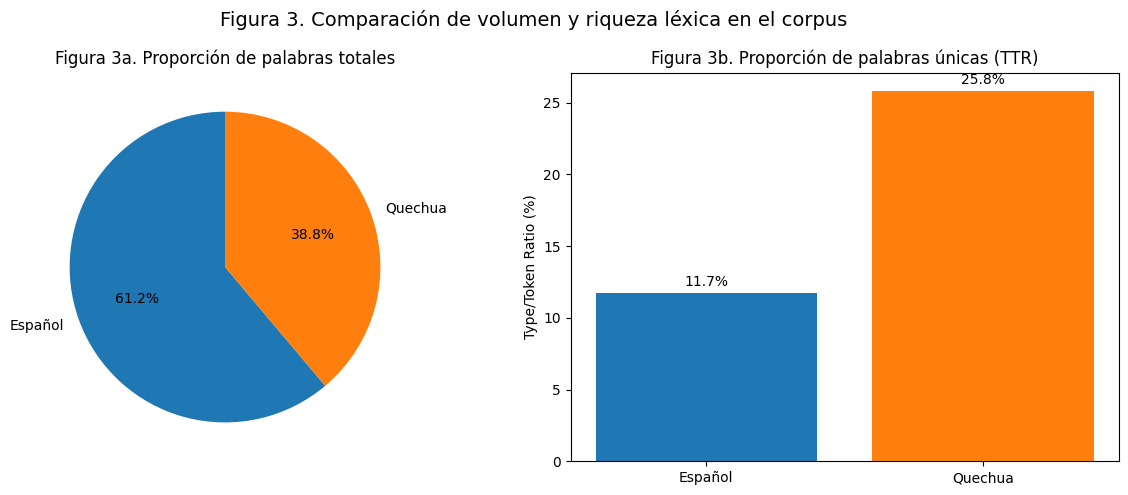

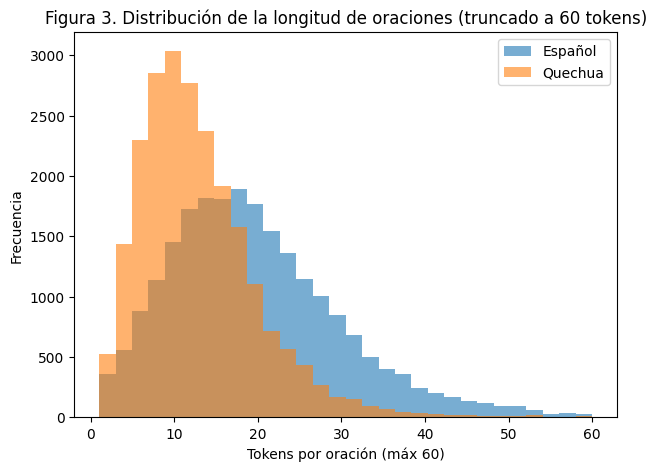

In [ ]:
# Figuras descriptivas del corpus consolidado (Figura 2a/2b y Figura 3)
import matplotlib.pyplot as plt

# --- Datos base ---
esp_tokens = df_all["esp"].astype(str).str.split().map(len)
quz_tokens = df_all["quz"].astype(str).str.split().map(len)

total_tokens_esp = int(esp_tokens.sum())
total_tokens_quz = int(quz_tokens.sum())

unique_tokens_esp = len({tok.lower() for sent in df_all["esp"].astype(str) for tok in sent.split()})
unique_tokens_quz = len({tok.lower() for sent in df_all["quz"].astype(str) for tok in sent.split()})

# TTR (type/token ratio en %)
ttr_esp = 100 * unique_tokens_esp / total_tokens_esp
ttr_quz = 100 * unique_tokens_quz / total_tokens_quz

# =========================
# Figura 2 (compuesta): 2a + 2b
# =========================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Figura 2a: Torta (palabras totales) ---
axes[0].pie([total_tokens_esp, total_tokens_quz],
            labels=["Español", "Quechua"],
            autopct="%1.1f%%",
            startangle=90,
            colors=["#1f77b4", "#ff7f0e"])
axes[0].set_title("Figura 3a. Proporción de palabras totales")

# --- Figura 2b: Barras (TTR %) ---
axes[1].bar(["Español", "Quechua"], [ttr_esp, ttr_quz],
            color=["#1f77b4", "#ff7f0e"])
axes[1].set_ylabel("Type/Token Ratio (%)")
axes[1].set_title("Figura 3b. Proporción de palabras únicas (TTR)")
for i, val in enumerate([ttr_esp, ttr_quz]):
    axes[1].text(i, val + 0.5, f"{val:.1f}%", ha="center", fontsize=10)

plt.suptitle("Figura 3. Comparación de volumen y riqueza léxica en el corpus", fontsize=14)
plt.tight_layout()
plt.show()

# =========================
# Figura 3: Histograma comparativo (tokens por oración) — truncado a 60 tokens
# =========================
plt.figure(figsize=(7,5))
plt.hist(esp_tokens[esp_tokens <= 60], bins=30, alpha=0.6, label="Español", color="#1f77b4")
plt.hist(quz_tokens[quz_tokens <= 60], bins=30, alpha=0.6, label="Quechua", color="#ff7f0e")
plt.xlabel("Tokens por oración (máx 60)")
plt.ylabel("Frecuencia")
plt.title("Figura 3. Distribución de la longitud de oraciones (truncado a 60 tokens)")
plt.legend()
plt.show()